# Skeleton visualization across input sources

Visualize skeletons from each input source in NTU-25 layout, with:
- **Multiple perspectives** (front, side, top, isometric) — to confirm shape is human in 3D, not just one projection
- **Interactive frame slider** — to scrub through time and catch joint-swapping or scale jumps

Sources:
- **MotionBert** (`motionBert_cropped_iou`, 17 joints) → NTU-25
- **MediaPipe World** (`world_mp_cropped_iou`, 33 joints) → NTU-25
- **MediaPipe Camera** (`camera_mp_cropped_iou`, 33 joints) → NTU-25  *(broken for pretrained encoders; shown for comparison)*
- **NTU120** reference sample from `MAMP/ntu120/NTU120_XSub.npz`

Requires: `pip install ipywidgets matplotlib numpy` (you probably have these already).

In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import ipywidgets as widgets
from IPython.display import display

%matplotlib inline

from data.skeletonMapping import (
    convertVideoMBtoNTU,
    convertVideoMPtoNTU,
    scale_normalize_to_ntu,
    NTU_REF_SPINE_LEN,
)
from data.PoseDataset import load_video_h5

print('Project root:', PROJECT_ROOT)
print('NTU_REF_SPINE_LEN:', NTU_REF_SPINE_LEN)

Project root: /code/jjiang23/BalanceTestThesis
NTU_REF_SPINE_LEN: 0.196


## Skeleton topology + multi-view plotter

In [2]:
NTU_EDGES = [
    # spine
    (0, 1), (1, 20), (20, 2), (2, 3),
    # left arm + hand tips
    (20, 4), (4, 5), (5, 6), (6, 7), (7, 21), (7, 22),
    # right arm + hand tips
    (20, 8), (8, 9), (9, 10), (10, 11), (11, 23), (11, 24),
    # left leg
    (0, 12), (12, 13), (13, 14), (14, 15),
    # right leg
    (0, 16), (16, 17), (17, 18), (18, 19),
]

# (name, elev, azim) — matplotlib 3d convention. y is plotted as the vertical (Z) axis.
VIEW_PRESETS = {
    'front':  (10, -90),   # looking along +z, camera in front of person
    'side':   (10,   0),   # looking along +x, profile view
    'top':    (89,  -90),  # looking straight down
    'iso':    (20,  45),   # isometric-ish
}


def to_numpy(x):
    if hasattr(x, 'cpu'):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def plot_skeleton(ax, joints25, title='', color='C0', lim=0.8, view='iso',
                  center_on_hip=True):
    """
    joints25: (25, 3) NTU-layout single frame.

    Plot axes:
        matplotlib X-axis  <- data x
        matplotlib Y-axis  <- data z   (depth)
        matplotlib Z-axis  <- data y   (vertical, up)
    """
    j = to_numpy(joints25)
    x, y, z = j[:, 0], j[:, 1], j[:, 2]

    for a, b in NTU_EDGES:
        ax.plot([x[a], x[b]], [z[a], z[b]], [y[a], y[b]], color=color, lw=1.5)
    ax.scatter(x, z, y, color=color, s=12)
    ax.scatter([x[0]], [z[0]], [y[0]], color='black', s=40, label='hip (0)')
    ax.scatter([x[3]], [z[3]], [y[3]], color='red',   s=40, label='head (3)')

    if center_on_hip:
        cx, cy, cz = x[0], y[0], z[0]
    else:
        cx, cy, cz = 0.0, 0.0, 0.0
    ax.set_xlim(cx - lim, cx + lim)
    ax.set_ylim(cz - lim, cz + lim)
    ax.set_zlim(cy - lim, cy + lim)

    ax.set_xlabel('x'); ax.set_ylabel('z'); ax.set_zlabel('y (up)')
    ax.set_title(title)
    elev, azim = VIEW_PRESETS[view]
    ax.view_init(elev=elev, azim=azim)


def plot_skeleton_all_views(joints25, suptitle='', color='C0', lim=0.8, figsize=(16, 4)):
    """Plot 4 perspectives of one frame side-by-side."""
    fig = plt.figure(figsize=figsize)
    for i, view in enumerate(VIEW_PRESETS):
        ax = fig.add_subplot(1, 4, i + 1, projection='3d')
        plot_skeleton(ax, joints25, title=view, color=color, lim=lim, view=view)
        if i == 0:
            ax.legend(loc='upper right', fontsize=7)
    fig.suptitle(suptitle, y=1.02, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Load one sequence from each source

In [3]:
# --- Adjust paths if needed ---
H5_LIST = '/code/jjiang23/pathml/aim2_balance/processed_files/all_h5_files.txt'
NTU120_NPZ = '/data2/pathml/MAMP/ntu120/NTU120_XSub.npz'
FILE_IDX  = 123  # which h5 file
with open(H5_LIST, 'r') as f:
    h5_files = [line.strip() for line in f.readlines()]
h5_path = h5_files[FILE_IDX]
print('Loading from:', h5_path)

# ── Helpers: joint mapping ONLY, no axis transformation ─────────────────────
# These let us show what the skeleton looks like BEFORE the axis fix,
# so the "original axes" vs "axis-remapped" difference is visually obvious.
from data.skeletonMapping import (
    getCalculatedMBKPs, ntu_to_MB_Mapping,
    getCalculatedMPKPs, ntu_to_MP_Mapping,
)

def _mb_joints_only(kps_frame):
    """MB-17 → NTU-25 joint indices WITHOUT the H3.6M→NTU axis remap.
    H3.6M z=vertical but plotted as depth → person appears LYING FLAT."""
    ntu = np.zeros((25, 3), dtype=np.float32)
    for i, name in ntu_to_MB_Mapping.items():
        kps = getCalculatedMBKPs(kps_frame)
        if name in kps:
            ntu[i] = kps[name]
    return ntu

def _mp_joints_only(kps_frame):
    """MP-33 → NTU-25 joint indices WITHOUT the y-flip.
    MP is y-down; NTU expects y-up → person appears UPSIDE DOWN."""
    ntu = np.zeros((25, 3), dtype=np.float32)
    kps = getCalculatedMPKPs(kps_frame)
    for i, name in ntu_to_MP_Mapping.items():
        if name in kps:
            ntu[i] = kps[name]
    return ntu

# ── Load raw keypoints ───────────────────────────────────────────────────────
mb_raw_kps  = load_video_h5(h5_path, 'motionBert_cropped_iou', allPhases=False)[0]   # (T, 17, 3)
mpw_raw_kps = load_video_h5(h5_path, 'world_mp_cropped_iou',   allPhases=False)[0]   # (T, 33, 3)
mpc_raw_kps = load_video_h5(h5_path, 'camera_mp_cropped_iou',  allPhases=False)[0]   # (T, 33, 3)

# Stage 1: joints mapped, NO axis fix (should look wrong)
mb_preconv  = np.stack([_mb_joints_only(mb_raw_kps[t])  for t in range(mb_raw_kps.shape[0])])
mpw_preconv = np.stack([_mp_joints_only(mpw_raw_kps[t]) for t in range(mpw_raw_kps.shape[0])])

# Stage 2: axis fix applied, no scale norm (was previously mislabelled "raw")
mb_seq  = convertVideoMBtoNTU(mb_raw_kps)
mpw_seq = convertVideoMPtoNTU(mpw_raw_kps)
mpc_seq = convertVideoMPtoNTU(mpc_raw_kps)

# Stage 3: axis fix + scale normalization (ready for MAMP/MAE)
def normalize_seq(seq_TVC):
    arr = to_numpy(seq_TVC)[None]        # (1, T, V, C)
    return scale_normalize_to_ntu(arr)[0]  # (T, V, C)

mb_seq_n  = normalize_seq(mb_seq)
mpw_seq_n = normalize_seq(mpw_seq)
mpc_seq_n = normalize_seq(mpc_seq)

npz = np.load(NTU120_NPZ)
ntu120_seq = npz['x_train'][0].reshape(300, 2, 25, 3)[:, 0]   # (T, 25, 3) body 0

# ── SOURCES dict ─────────────────────────────────────────────────────────────
# "original axes"  = joint mapping only, NO axis fix  → looks WRONG (lying/flipped)
# "axis-remapped"  = axis fix only, no scale norm     → correct shape, slightly off scale
# "normed"         = axis fix + scale norm            → what MAMP/MAE receives
SOURCES = {
    'MB (original axes)':        to_numpy(mb_preconv),   # lying flat — H3.6M z treated as depth
    'MB (axis-remapped)':        to_numpy(mb_seq),       # correct orientation, raw scale
    'MB (axis+scale normed)':    to_numpy(mb_seq_n),     # correct orientation + scale
    'world_mp (original axes)':  to_numpy(mpw_preconv),  # upside-down — MP y-down
    'world_mp (axis-remapped)':  to_numpy(mpw_seq),      # correct orientation, raw scale
    'world_mp (axis-remapped+ normed)':         to_numpy(mpw_seq_n),    # correct orientation + scale
    'camera_mp (axis-remapped)': to_numpy(mpc_seq),
    'camera_mp (normed)':        to_numpy(mpc_seq_n),
    'NTU120 reference':          to_numpy(ntu120_seq),
}

print('Shapes:')
for k, v in SOURCES.items():
    print(f'  {k:30s}: T={v.shape[0]}, range=[{v.min():.3f}, {v.max():.3f}]')


Loading from: /files/pathml/aim2/mediapipe_results/balance_test/heavy/cp/P13_Balc_2.h5


Shapes:
  MB (original axes)            : T=420, range=[-0.159, 1.212]
  MB (axis-remapped)            : T=420, range=[-0.204, 1.212]
  MB (axis+scale normed)        : T=420, range=[-0.187, 1.108]
  world_mp (original axes)      : T=420, range=[-0.612, 0.884]
  world_mp (axis-remapped)      : T=420, range=[-0.884, 0.612]
  world_mp (axis-remapped+ normed): T=420, range=[-0.716, 0.496]
  camera_mp (axis-remapped)     : T=420, range=[-0.979, 0.964]
  camera_mp (normed)            : T=420, range=[-1.271, 1.251]
  NTU120 reference              : T=300, range=[-0.960, 0.412]


## Multi-view: same frame from 4 angles for each source

Read each row left-to-right: **front** (camera looking at chest), **side** (profile), **top** (looking down), **isometric**. Check that:
- Head (red) is **up** in front/side views
- Top view shows a roughly symmetric body cross-section (shoulders + arms span left/right)
- Side view shows the body as a roughly vertical line with limbs extending forward/back

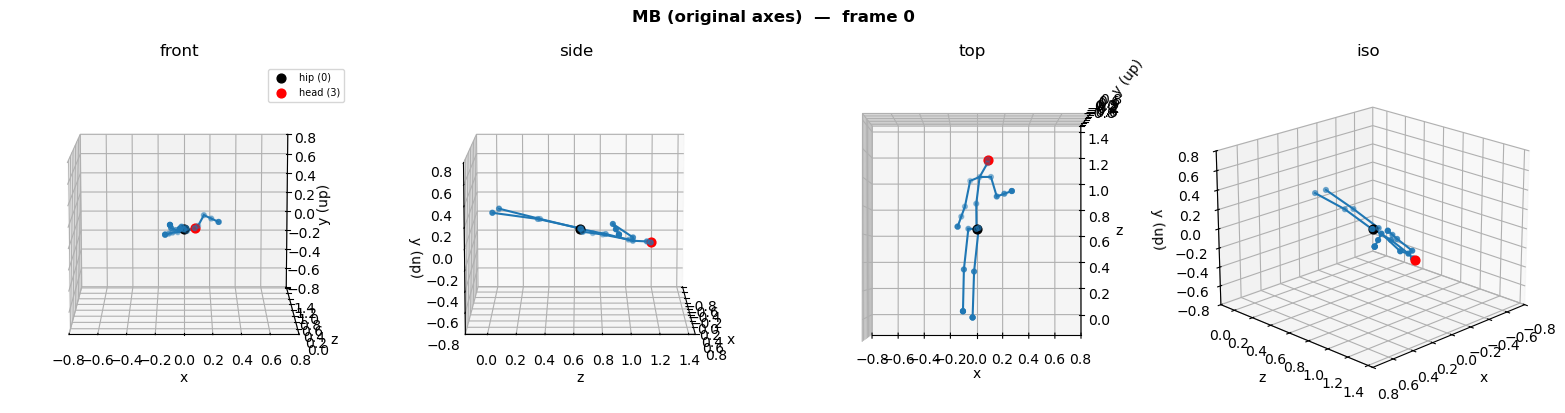

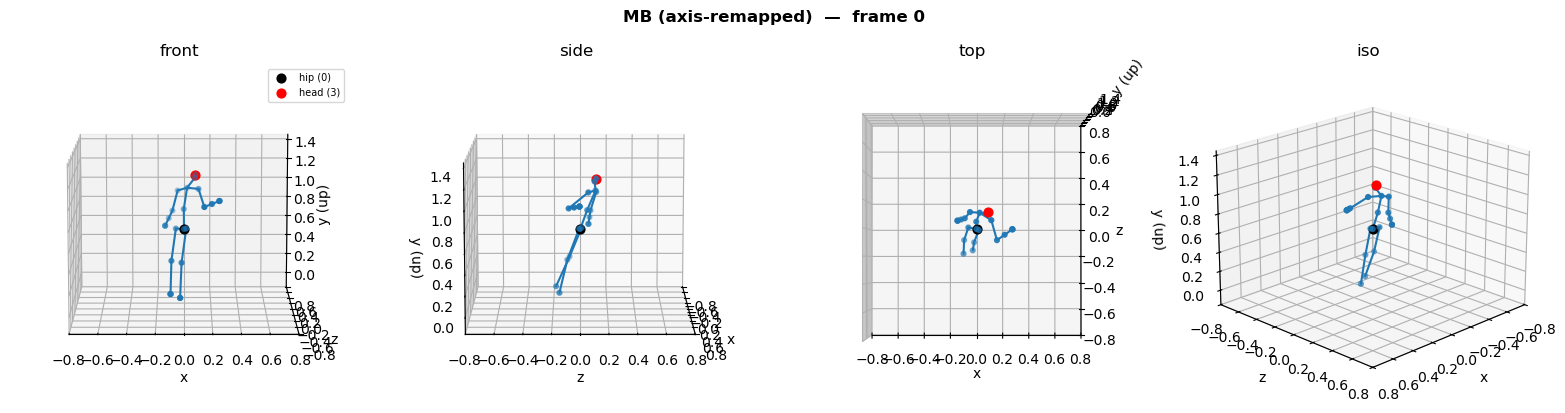

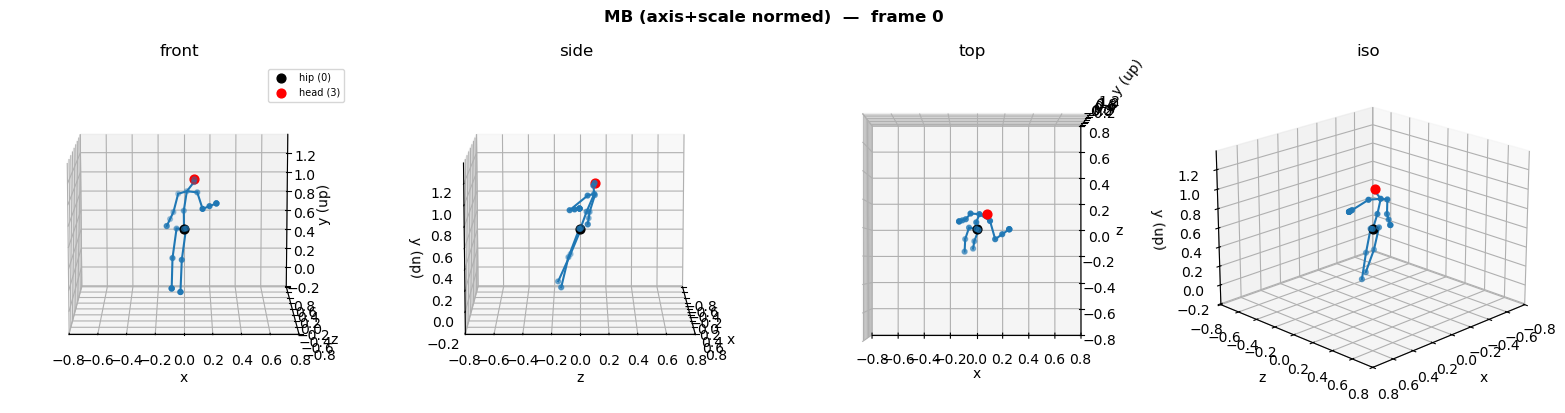

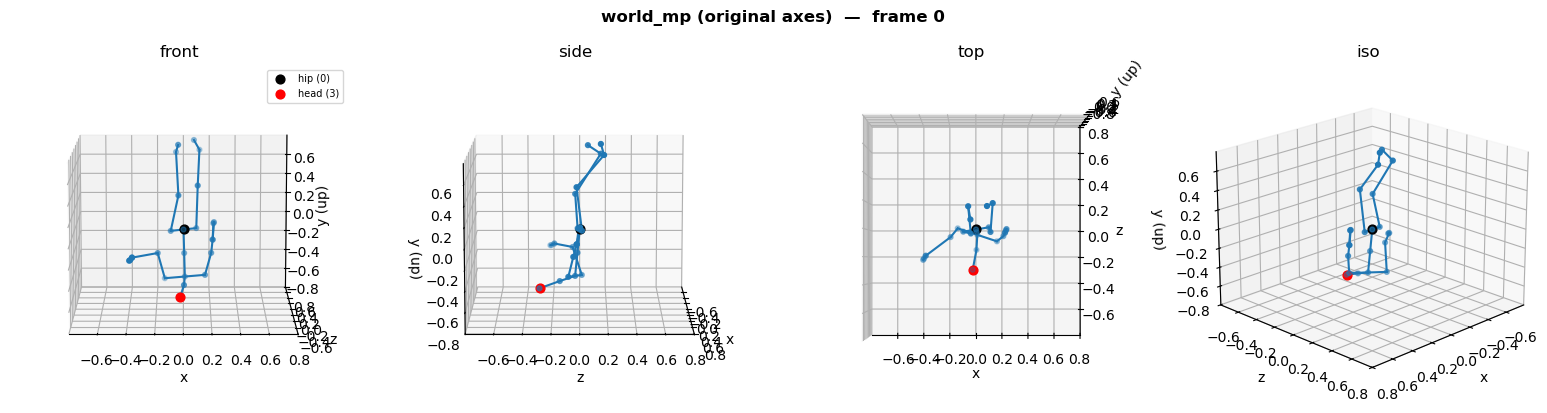

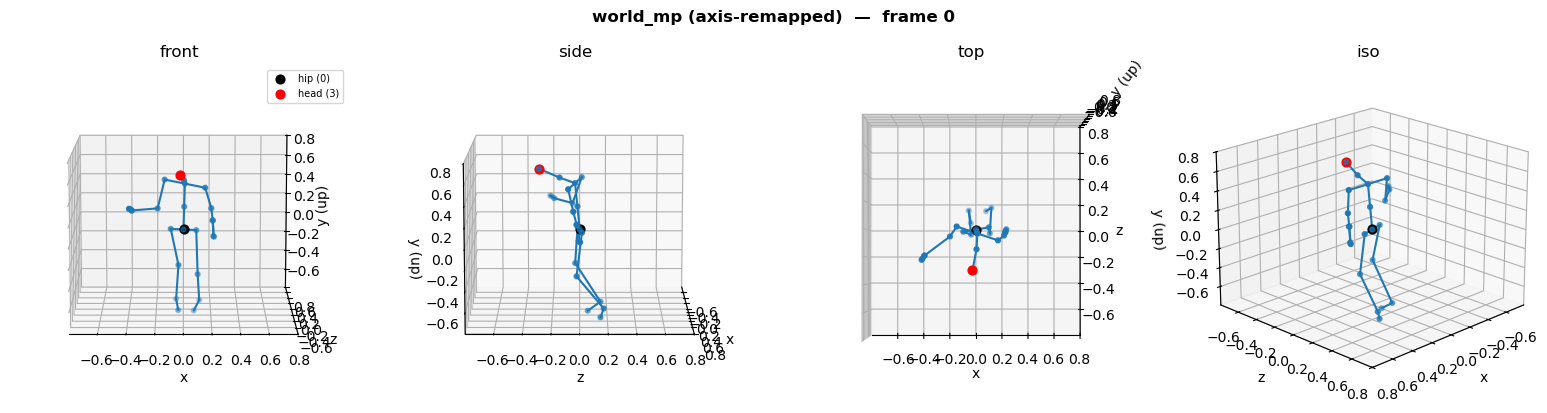

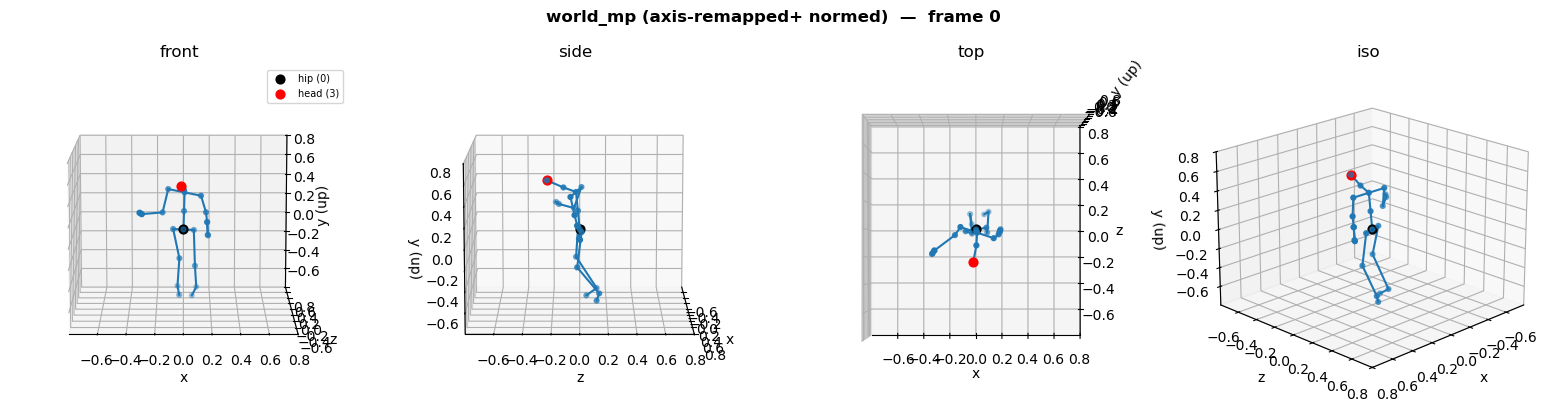

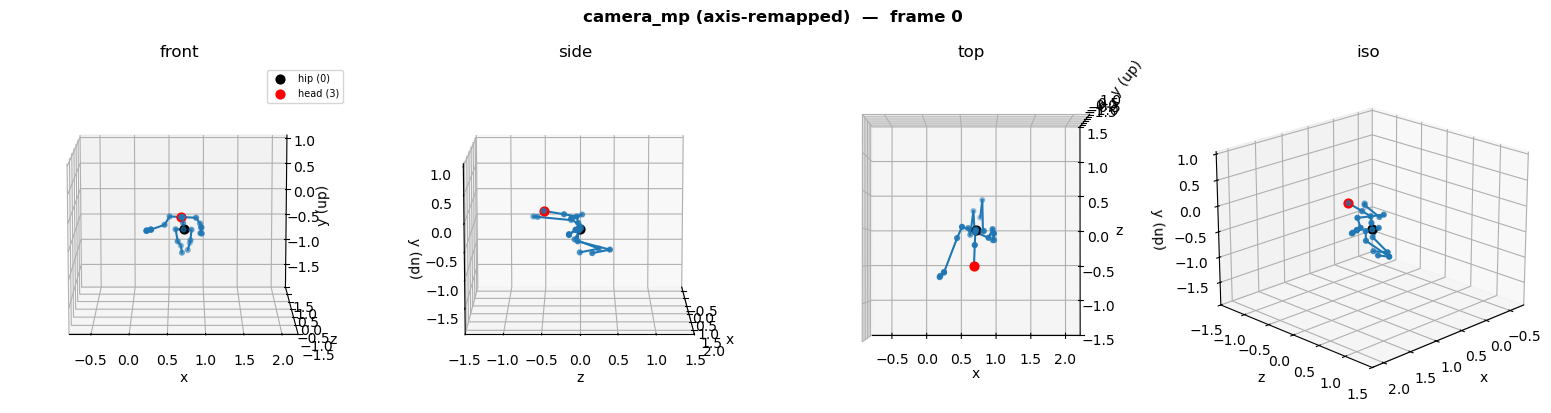

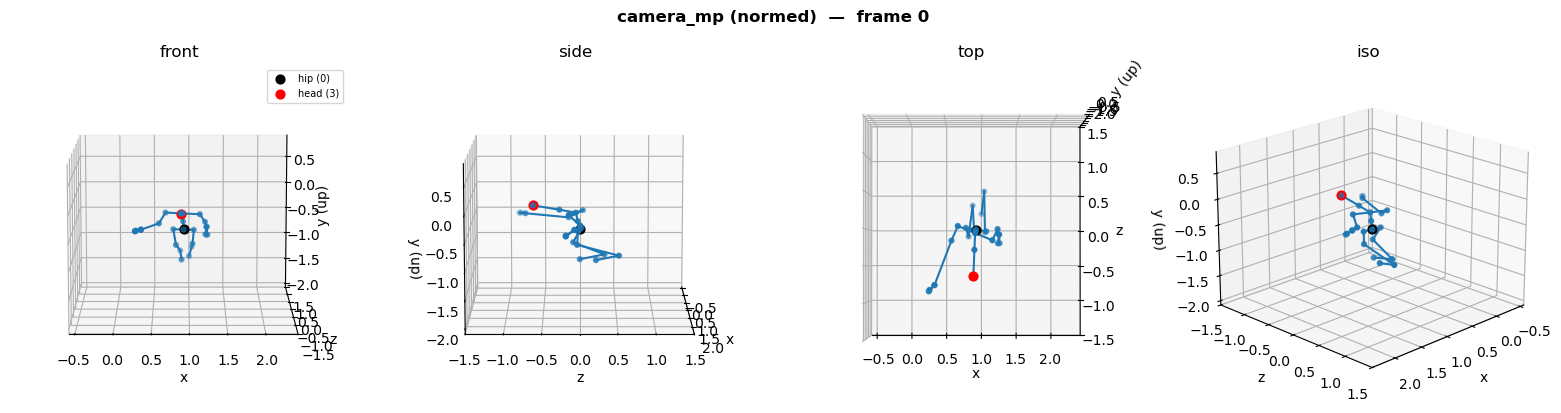

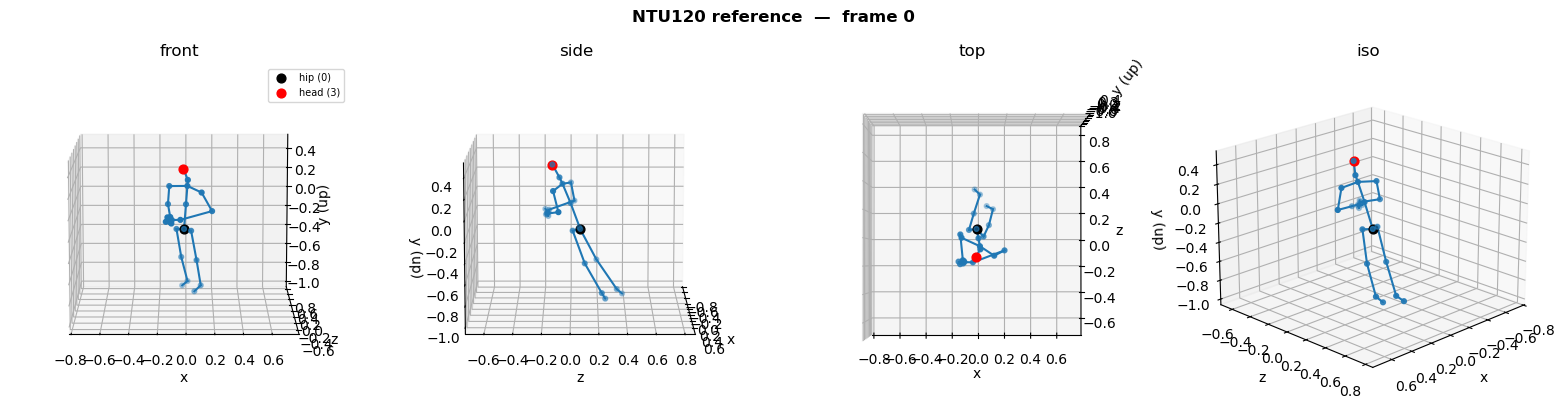

In [4]:
FRAME = 0  # change to inspect a different frame

for name, seq in SOURCES.items():
    if seq.shape[0] <= FRAME:
        print(f'Skipping {name}: only {seq.shape[0]} frames')
        continue
    # Use a wider lim for camera_mp because z is anisotropically scaled
    lim = 1.5 if 'camera_mp' in name else 0.8
    plot_skeleton_all_views(seq[FRAME], suptitle=f'{name}  —  frame {FRAME}', lim=lim)

## Interactive: frame slider + view + source

Drag the frame slider to scrub through time. Toggle the source and view dropdowns to switch what's shown. Use this to:
- Spot frames where MB looks deformed (joint swaps, sudden scale jumps)
- Compare MB and NTU120 at matched poses
- Confirm world_mp tracks smoothly without jitter

In [5]:
max_T = max(seq.shape[0] for seq in SOURCES.values())

out = widgets.Output()

def render(source, frame, view, lim):
    with out:
        out.clear_output(wait=True)
        seq = SOURCES[source]
        T = seq.shape[0]
        f = min(frame, T - 1)
        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection='3d')
        plot_skeleton(ax, seq[f], title=f'{source}\nframe {f}/{T-1}  [{view}]',
                      lim=lim, view=view)
        ax.legend(loc='upper right', fontsize=8)
        plt.tight_layout()
        plt.show()

source_w = widgets.Dropdown(options=list(SOURCES.keys()), value='MB (scale-normed)', description='source:')
frame_w  = widgets.IntSlider(min=0, max=max_T - 1, value=0, step=1, description='frame:',
                             continuous_update=False, layout=widgets.Layout(width='600px'))
view_w   = widgets.Dropdown(options=list(VIEW_PRESETS.keys()), value='iso', description='view:')
lim_w    = widgets.FloatSlider(min=0.2, max=2.0, value=0.8, step=0.1, description='zoom:',
                                continuous_update=False)

ui = widgets.VBox([
    widgets.HBox([source_w, view_w, lim_w]),
    frame_w,
    out,
])

def _on_change(_=None):
    render(source_w.value, frame_w.value, view_w.value, lim_w.value)

for w in (source_w, frame_w, view_w, lim_w):
    w.observe(_on_change, names='value')

display(ui)
_on_change()  # initial render

TraitError: Invalid selection: value not found

## Side-by-side compare: 4 sources, single view, frame slider

Lock everything to the same frame index and view to make MB vs world_mp vs NTU120 directly comparable.

In [ ]:
compare_sources = ['NTU120 reference', 'MB (scale-normed)', 'world_mp (normed)', 'camera_mp (normed)']
compare_max_T = min(SOURCES[s].shape[0] for s in compare_sources)

out2 = widgets.Output()

def render_compare(frame, view, lim):
    with out2:
        out2.clear_output(wait=True)
        fig = plt.figure(figsize=(20, 5))
        colors = ['C2', 'C0', 'C1', 'C3']
        for i, (name, color) in enumerate(zip(compare_sources, colors)):
            seq = SOURCES[name]
            f = min(frame, seq.shape[0] - 1)
            ax = fig.add_subplot(1, 4, i + 1, projection='3d')
            l = 1.5 if 'camera_mp' in name else lim
            plot_skeleton(ax, seq[f], title=f'{name}\nframe {f}', color=color, lim=l, view=view)
        plt.tight_layout()
        plt.show()

frame_w2 = widgets.IntSlider(min=0, max=compare_max_T - 1, value=0, step=1, description='frame:',
                              continuous_update=False, layout=widgets.Layout(width='600px'))
view_w2  = widgets.Dropdown(options=list(VIEW_PRESETS.keys()), value='iso', description='view:')
lim_w2   = widgets.FloatSlider(min=0.2, max=2.0, value=0.8, step=0.1, description='zoom:',
                                continuous_update=False)

ui2 = widgets.VBox([
    widgets.HBox([view_w2, lim_w2]),
    frame_w2,
    out2,
])

def _on_change2(_=None):
    render_compare(frame_w2.value, view_w2.value, lim_w2.value)

for w in (frame_w2, view_w2, lim_w2):
    w.observe(_on_change2, names='value')

display(ui2)
_on_change2()

## Sanity numbers

Spine length and y-axis convention should match across MB / world_mp / NTU120 after normalization.

In [ ]:
def spine_len(frame):
    f = to_numpy(frame)
    return float(np.linalg.norm(f[20] - f[1]))

def axis_check(frame, name):
    f = to_numpy(frame)
    print(f'{name:30s}  spine={spine_len(f):.4f}   '
          f'head_y={f[3,1]:+.3f}  hip_y={f[0,1]:+.3f}  toe_y={f[15,1]:+.3f}   '
          f'x_range=[{f[:,0].min():+.3f},{f[:,0].max():+.3f}]  '
          f'y_range=[{f[:,1].min():+.3f},{f[:,1].max():+.3f}]  '
          f'z_range=[{f[:,2].min():+.3f},{f[:,2].max():+.3f}]')

FRAME = 0
for name, seq in SOURCES.items():
    axis_check(seq[FRAME], name)
print(f'\nTarget spine length (NTU120 mean): {NTU_REF_SPINE_LEN}')

MB (raw)                        spine=0.2095   head_y=+1.160  hip_y=+0.645  toe_y=+0.046   x_range=[-0.139,+0.259]  y_range=[+0.000,+1.160]  z_range=[-0.180,+0.117]
MB (scale-normed)               spine=0.1916   head_y=+1.061  hip_y=+0.590  toe_y=+0.042   x_range=[-0.127,+0.237]  y_range=[+0.000,+1.061]  z_range=[-0.164,+0.107]
world_mp (raw)                  spine=0.2314   head_y=+0.598  hip_y=+0.002  toe_y=-0.856   x_range=[-0.393,+0.225]  y_range=[-0.856,+0.598]  z_range=[-0.298,+0.177]
world_mp (normed)               spine=0.1874   head_y=+0.485  hip_y=+0.002  toe_y=-0.694   x_range=[-0.318,+0.182]  y_range=[-0.694,+0.485]  z_range=[-0.241,+0.143]
camera_mp (raw)                 spine=0.1221   head_y=-0.112  hip_y=-0.453  toe_y=-0.880   x_range=[+0.212,+0.961]  y_range=[-0.887,-0.112]  z_range=[-0.656,+0.416]
camera_mp (normed)              spine=0.1584   head_y=-0.146  hip_y=-0.588  toe_y=-1.142   x_range=[+0.275,+1.248]  y_range=[-1.151,-0.146]  z_range=[-0.852,+0.540]
NTU120 ref